<a href="https://colab.research.google.com/github/sajjkavinda/ML-based-Intrution-detection-system/blob/main/Feature_Importance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Feature Importance Analysis

Feature importance is extracted from:
- Decision Tree
- Random Forest
- XGBoost

The analysis helps identify which CIC-IDS2018 flow characteristics contribute most to intrusion detection.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import libraries

In [5]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

Set path for the Dataset

In [7]:
from types import ModuleType
PROJECT_DIR = Path("/content/drive/MyDrive/MSc_Dissertation")

PROCESSED_DIR = PROJECT_DIR / "Dataset/Processed"

MODEL_DIR = PROJECT_DIR / "Results/Models"

Load Train data

In [4]:
with open(PROCESSED_DIR / "X_train.pkl", "rb") as f:
    X_train = pickle.load(f)


features = X_train.columns

Load saved models

In [8]:
dt = joblib.load(
    MODEL_DIR / "decision_tree_model.pkl"
)


rf = joblib.load(
    MODEL_DIR / "random_forest_model.pkl"
)


xgb = joblib.load(
    MODEL_DIR / "xgboost_model.pkl"
)

Decision Tree Feature Importance

In [9]:
dt_importance = pd.DataFrame(
    {
        "Feature": features,
        "Importance": dt.feature_importances_
    }
)


dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)


dt_importance.head(10)

,Feature,Importance
0,Fwd Seg Size Min,0.546109
18,Bwd IAT Min,0.432095
19,Bwd Pkt Len Mean,0.007211
15,Bwd Pkt Len Max,0.005319
1,Init Fwd Win Byts,0.003239
20,Init Bwd Win Byts,0.002239
8,Pkt Len Max,0.001413
6,Fwd Pkt Len Max,0.001348
10,Flow IAT Max,0.000702
7,Fwd IAT Mean,0.000179


Random Forest Feature Importance

In [10]:
rf_importance = pd.DataFrame(
    {
        "Feature": features,
        "Importance": rf.feature_importances_
    }
)


rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)


rf_importance.head(10)

,Feature,Importance
0,Fwd Seg Size Min,0.256302
1,Init Fwd Win Byts,0.074501
3,Bwd Pkts/s,0.065904
2,Tot Bwd Pkts,0.060819
9,Fwd Pkt Len Mean,0.051382
5,Flow IAT Mean,0.048192
11,Flow Pkts/s,0.047100
10,Flow IAT Max,0.046944
6,Fwd Pkt Len Max,0.046469
7,Fwd IAT Mean,0.040499


XGBoost Feature Importance

In [11]:
xgb_importance = pd.DataFrame(
    {
        "Feature": features,
        "Importance": xgb.feature_importances_
    }
)


xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)


xgb_importance.head(10)

,Feature,Importance
0,Fwd Seg Size Min,0.457846
18,Bwd IAT Min,0.307212
6,Fwd Pkt Len Max,0.146119
15,Bwd Pkt Len Max,0.028008
7,Fwd IAT Mean,0.012765
8,Pkt Len Max,0.011737
20,Init Bwd Win Byts,0.009384
12,ACK Flag Cnt,0.005452
24,Down/Up Ratio,0.005365
19,Bwd Pkt Len Mean,0.005281


Top 10 features

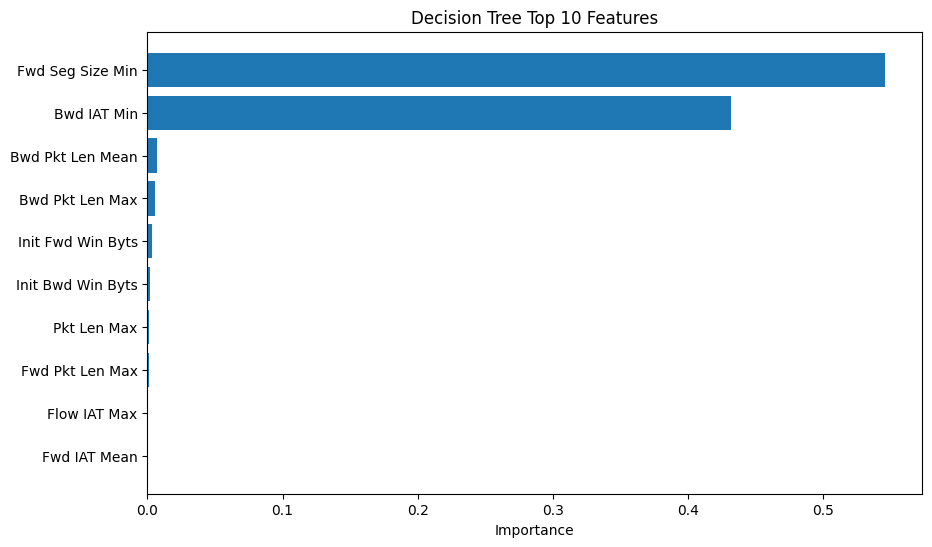

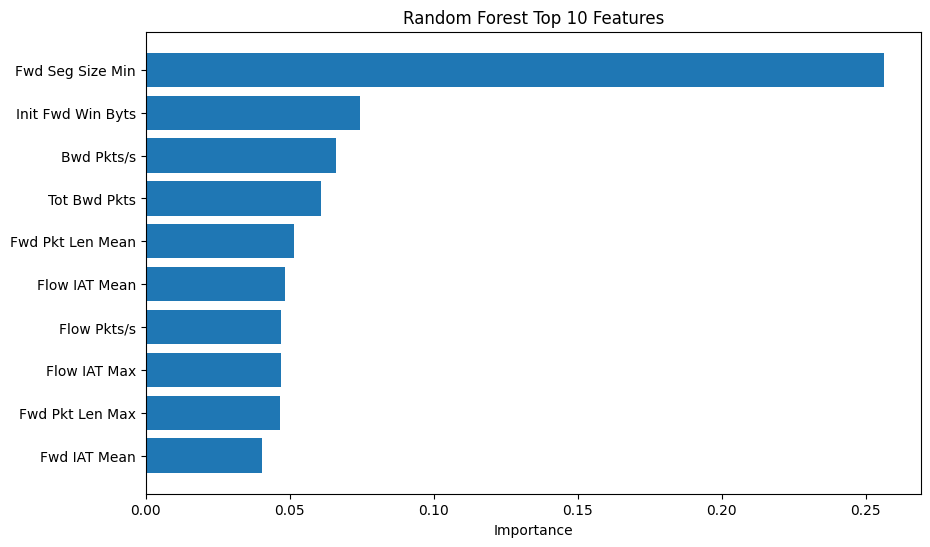

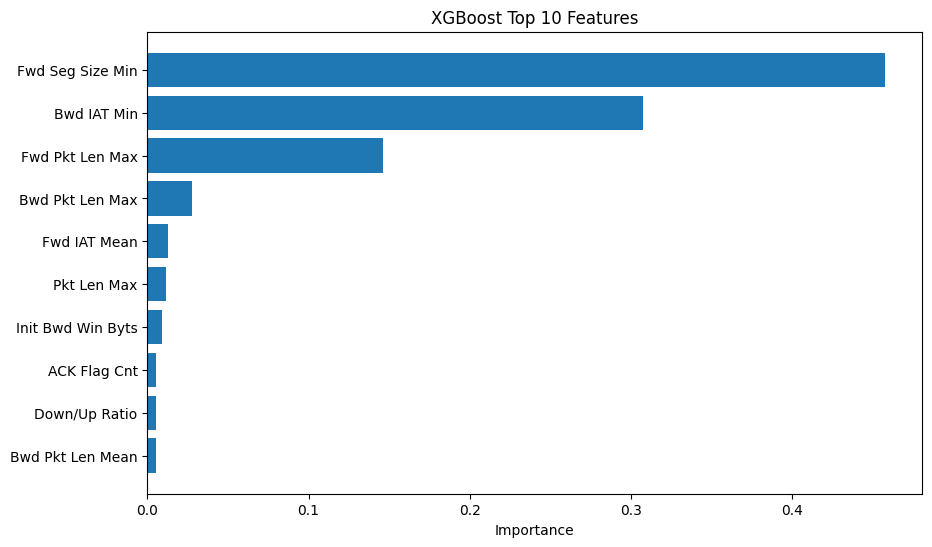

In [16]:
plt.figure(figsize=(10,6))

top = dt_importance.head(10)

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.title("Decision Tree Top 10 Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

plt.figure(figsize=(10,6))

top = rf_importance.head(10)

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.title("Random Forest Top 10 Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

plt.figure(figsize=(10,6))

top = xgb_importance.head(10)

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.title("XGBoost Top 10 Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

Save Plots

In [17]:
dt_importance.to_csv(
    PROJECT_DIR / "decision_tree_feature_importance.csv",
    index=False
)


rf_importance.to_csv(
    PROJECT_DIR / "random_forest_feature_importance.csv",
    index=False
)


xgb_importance.to_csv(
    PROJECT_DIR / "xgboost_feature_importance.csv",
    index=False
)